In [1]:
import kagglehub

# Download latest version
dataset_id = "akshaydattatraykhare/diabetes-dataset"
dataset_path = kagglehub.dataset_download(dataset_id)

print("Path to dataset files:", dataset_path)

Path to dataset files: C:\Users\Usuario\.cache\kagglehub\datasets\akshaydattatraykhare\diabetes-dataset\versions\1


In [2]:
import sys
import os

# add the 'src' directory as one where we can import modules
script_path = (
    r"D:\4_IA y ML en Cs Biol\Especializacion_ML_\Proyectos\1_DBT_Prediction\src\data"
)
sys.path.append(script_path)

# Ahora intenta importar
from data_loader import load_data

In [3]:
file_name = "diabetes.csv"
df = load_data(dataset_path, file_name)

Dataset loaded successfully. Shape: (768, 9)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
# Save dataset in raw folder
save_output_path = r"D:\4_IA y ML en Cs Biol\Especializacion_ML_\Proyectos\1_DBT_Prediction\data\raw\diabetes.csv"
df.to_csv(save_output_path, index=False)
print(f"Dataset guardado en: {save_output_path}")

Dataset guardado en: D:\4_IA y ML en Cs Biol\Especializacion_ML_\Proyectos\1_DBT_Prediction\data\raw\diabetes.csv


Targeg Variable = Outcome


1)_ Exploratory Data Analysis: Inspect, Understand and CleanData

1_ Variables Distributions (Histograms, KDE)

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
import pathlib

In [8]:
from pathlib import Path

dbt_data_path = Path(
    r"D:\4_IA y ML en Cs Biol\Especializacion_ML_\Proyectos\1_DBT_Prediction\data\raw\diabetes.csv"
)

# Verify if the file exists
if dbt_data_path.exists():
    dbt_df = pd.read_csv(dbt_data_path, encoding="utf-8")
else:
    raise FileNotFoundError(f"El archivo {dbt_data_path} no fue encontrado.")

In [9]:
dbt_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [10]:
import sys

scrip_distribution_path = (
    r"D:\4_IA y ML en Cs Biol\Especializacion_ML_\Proyectos\1_DBT_Prediction\src\EDA"
)
sys.path.append(scrip_distribution_path)

from distribution import plot_distribution, compute_skewness, plot_scatter

In [11]:
features = dbt_df[
    [
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age",
    ]
]
target = dbt_df["Outcome"]
features.head()
# We use the function plot_distribution and function plot_box to plot the distribution of the features
# the target variable have 2 values 0 and 1, so, we plot after into a histogram

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


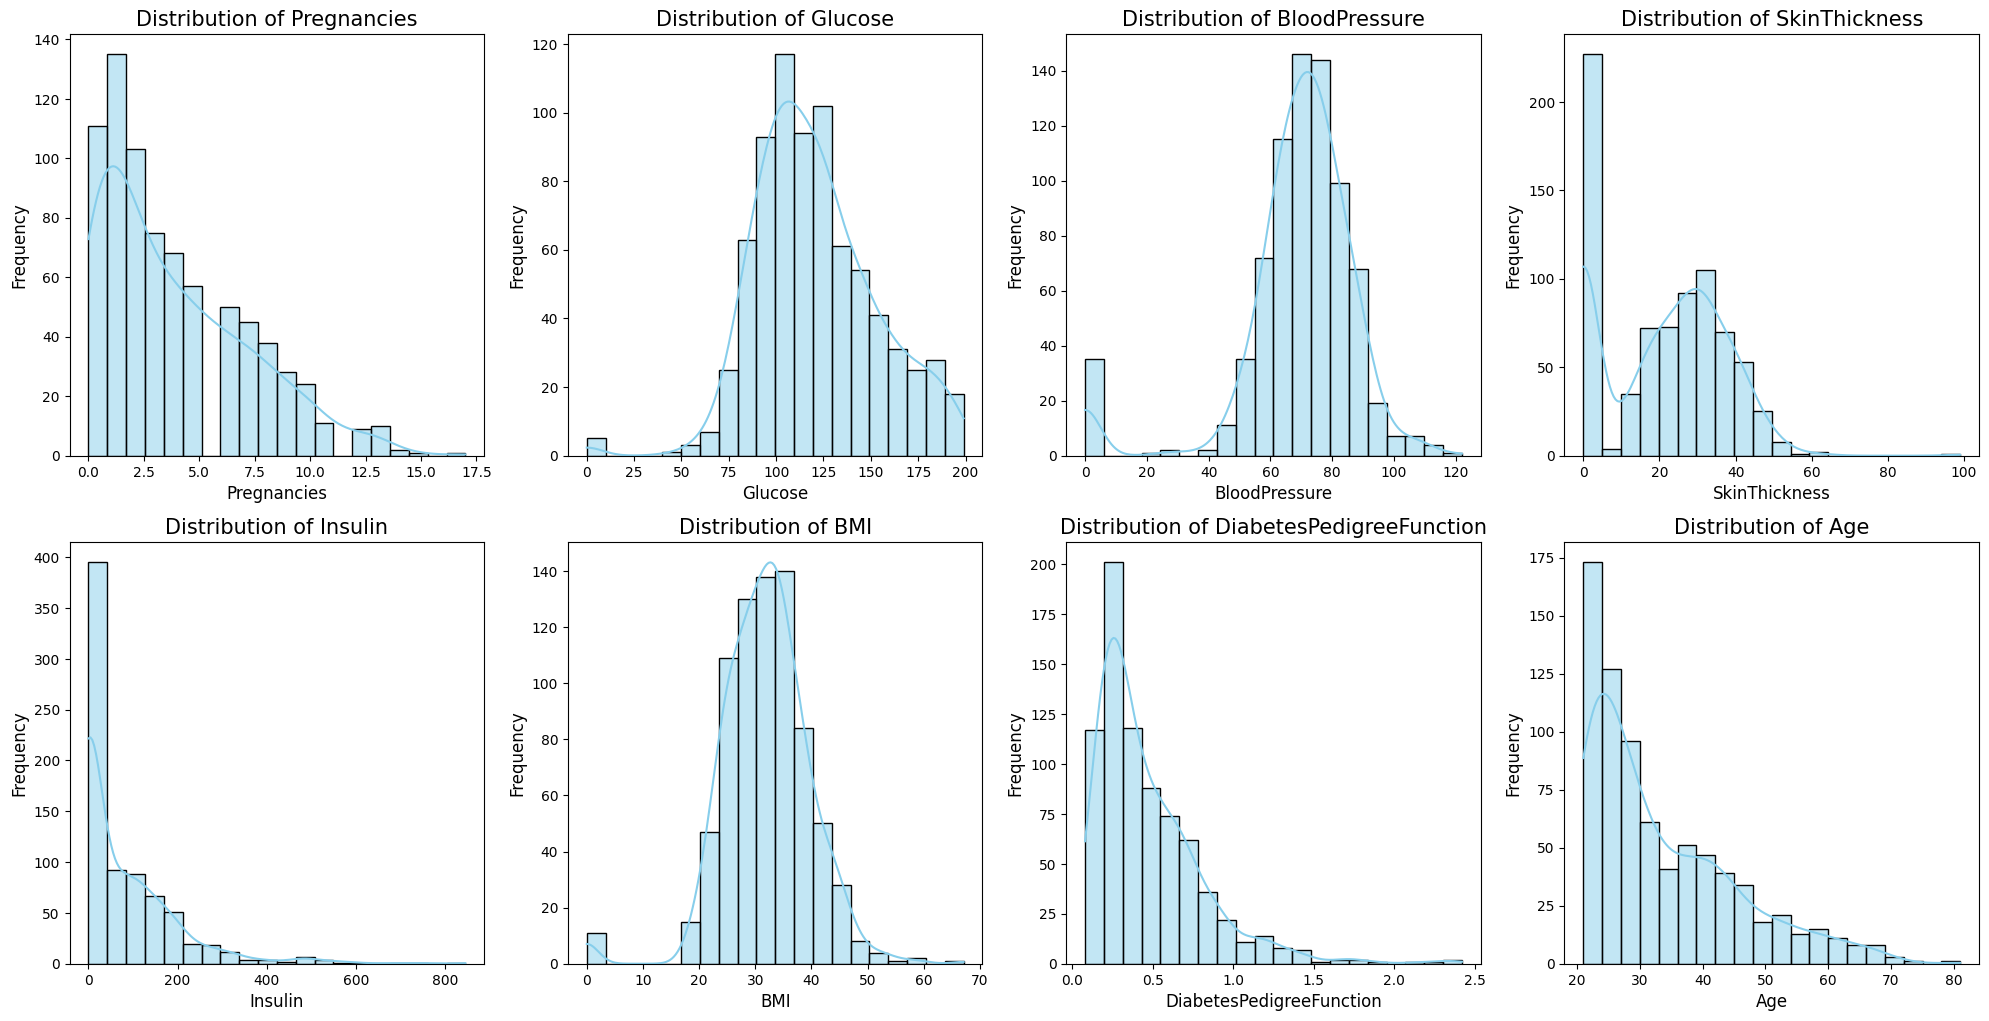

In [12]:
plot_distribution(features)

In [13]:
target_dbt_1 = dbt_df[dbt_df["Outcome"] == 1]
target_dbt_0 = dbt_df[dbt_df["Outcome"] == 0]

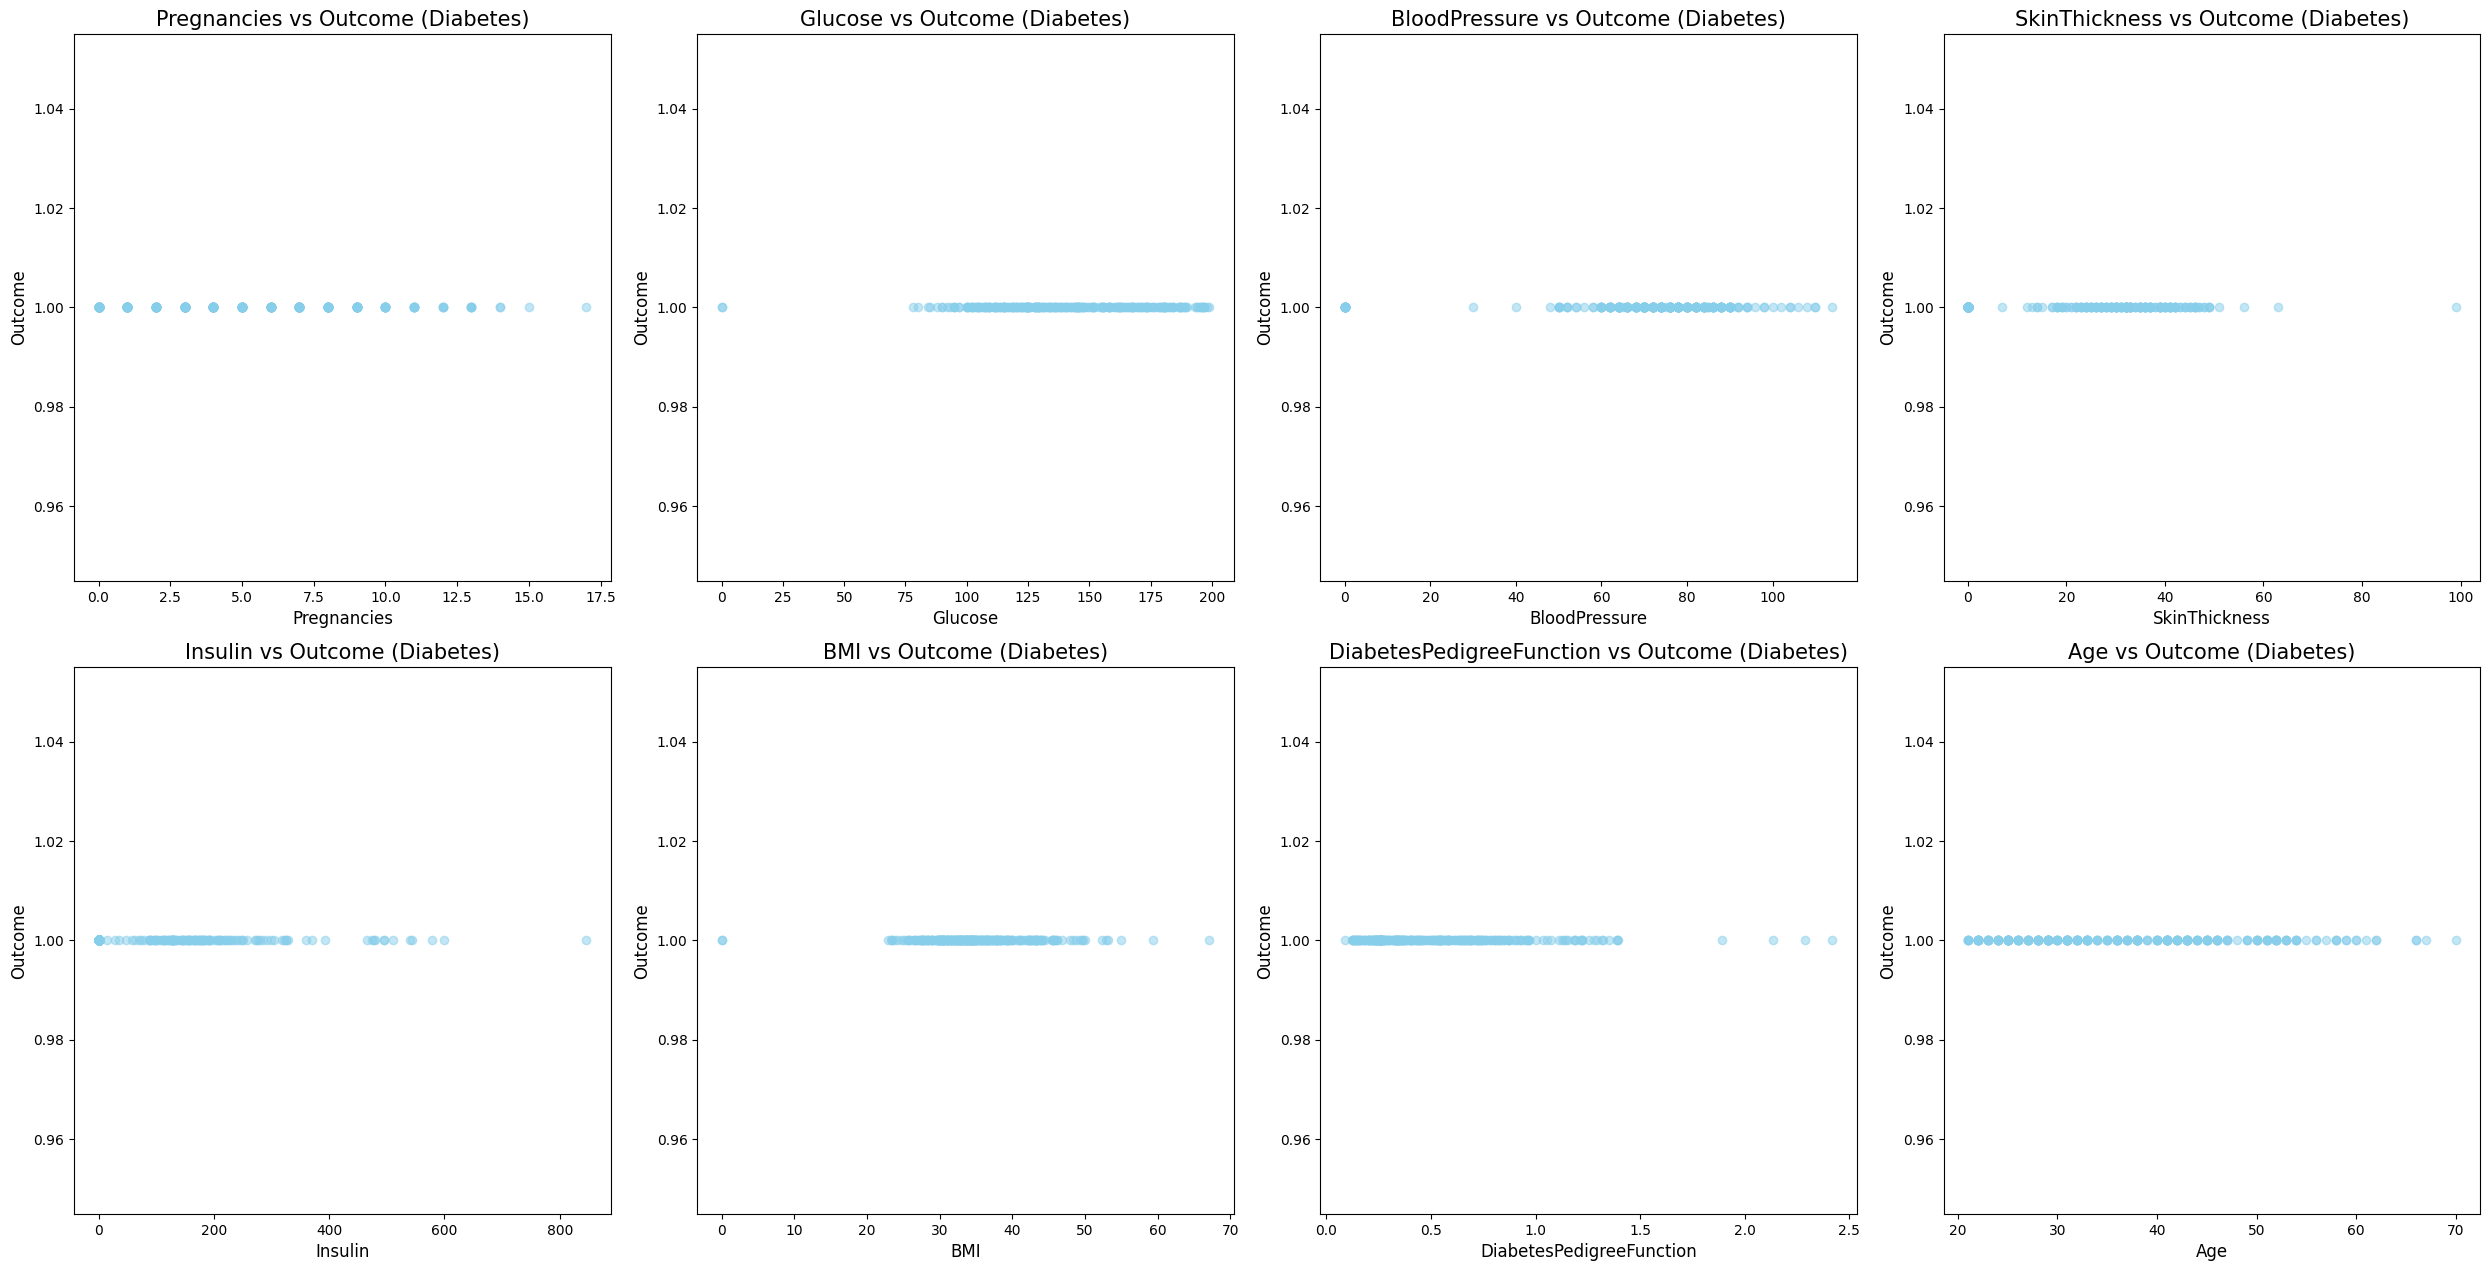

In [14]:
plot_scatter(target_dbt_1, "Outcome", title_suffix="Diabetes")

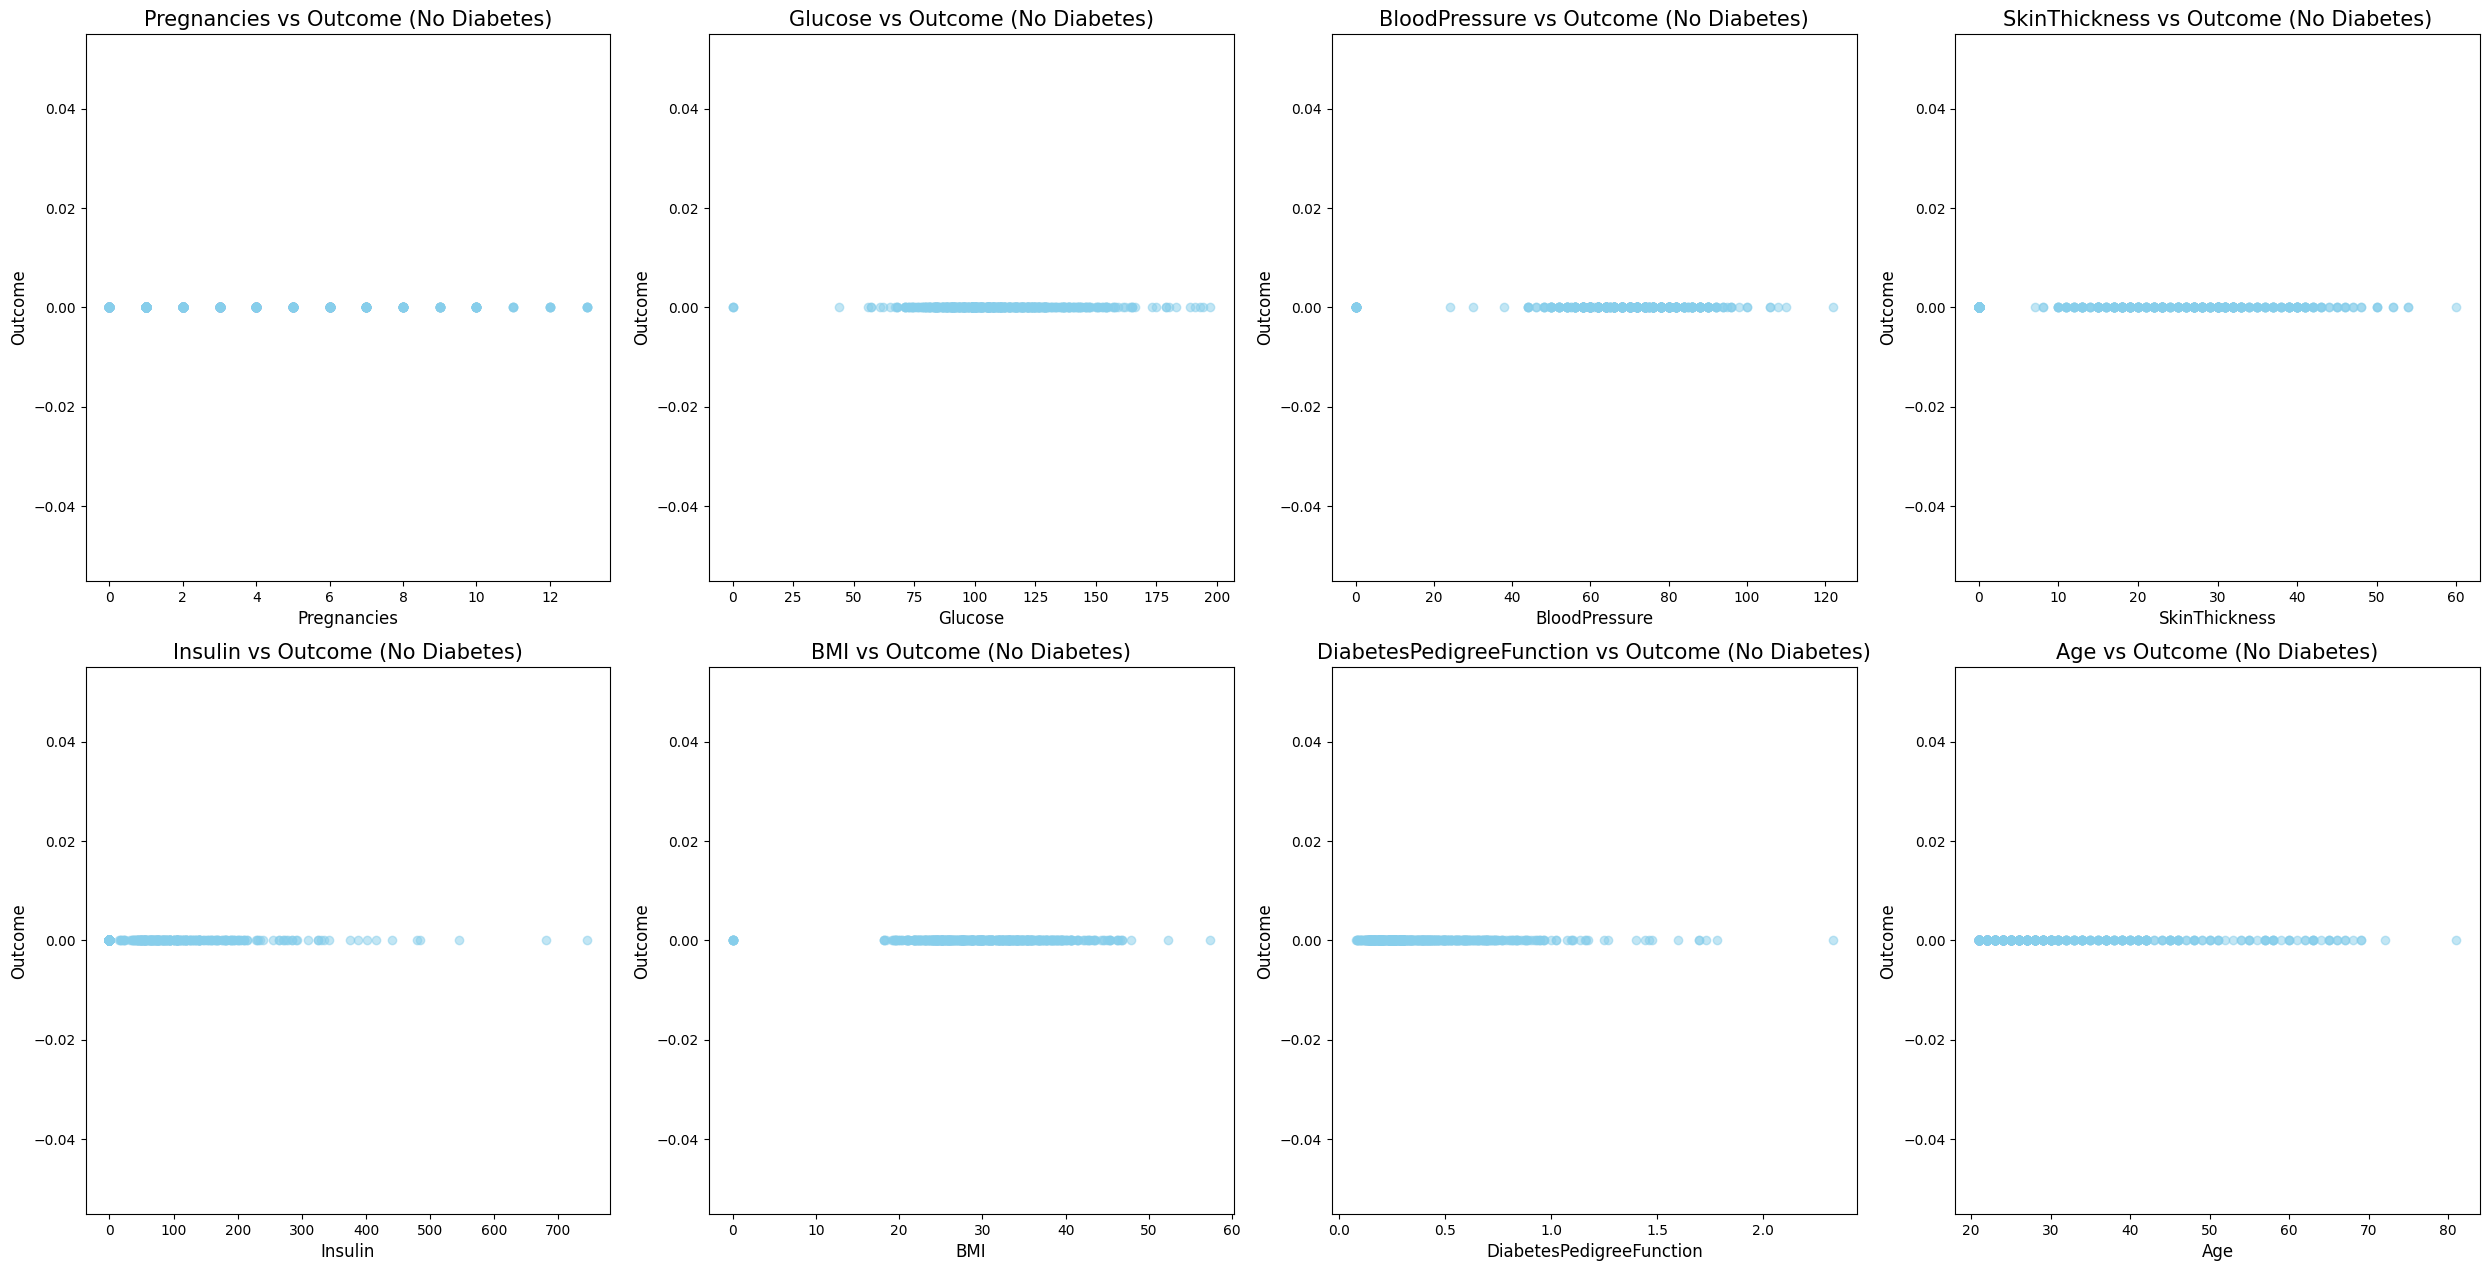

In [15]:
plot_scatter(target_dbt_0, "Outcome", title_suffix="No Diabetes")

In [16]:
#
skew_values = compute_skewness(features)
print(skew_values)

Pregnancies                 0.899912
Glucose                     0.173414
BloodPressure              -1.840005
SkinThickness               0.109159
Insulin                     2.267810
BMI                        -0.428143
DiabetesPedigreeFunction    1.916159
Age                         1.127389
dtype: float64


In [17]:
features.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


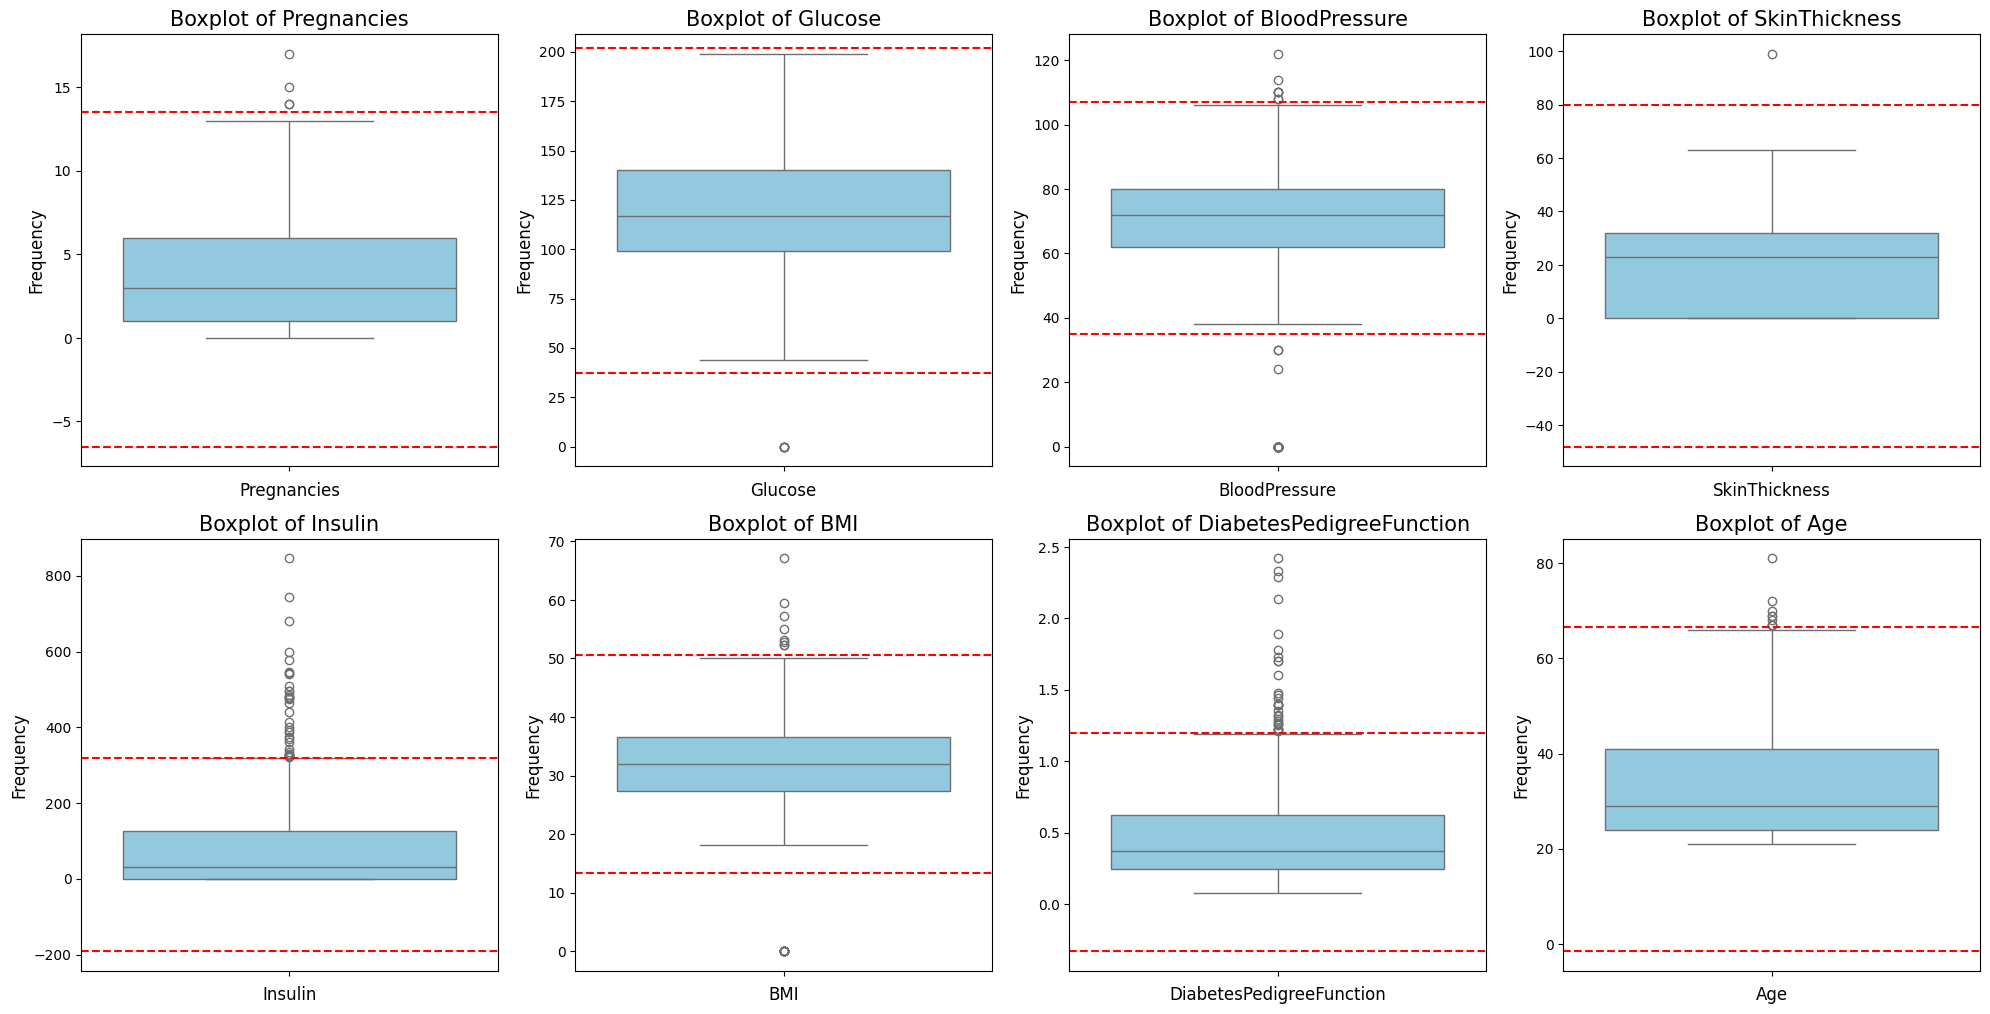

In [18]:
from outlier_id import plot_box

plot_box(features)

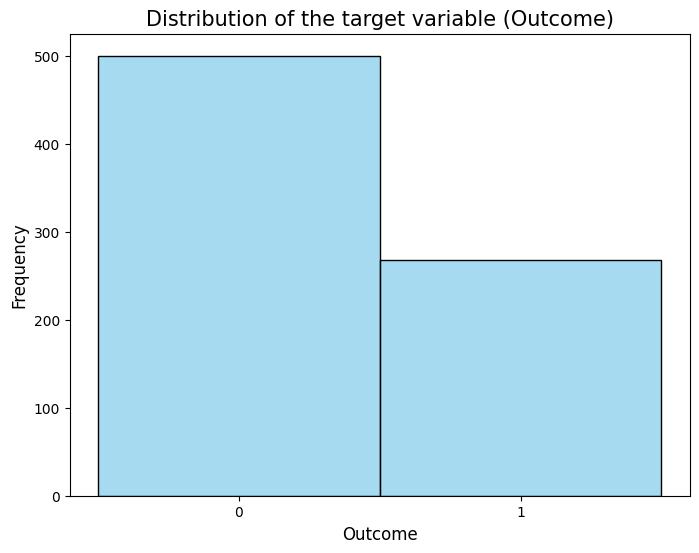

In [19]:
# Histogram of the target variable
plt.figure(figsize=(8, 6))
sns.histplot(
    target, discrete=True, bins=2, color="skyblue"
)  # Ajustar a valores discretos y 2 bins
plt.title("Distribution of the target variable (Outcome)", fontsize=15)
plt.xlabel("Outcome", fontsize=12)  # Etiqueta personalizada
plt.ylabel("Frequency", fontsize=12)  # Etiqueta personalizada
plt.xticks([0, 1])  # Asegurarse de que solo aparezcan 0 y 1 en el eje X
plt.show()

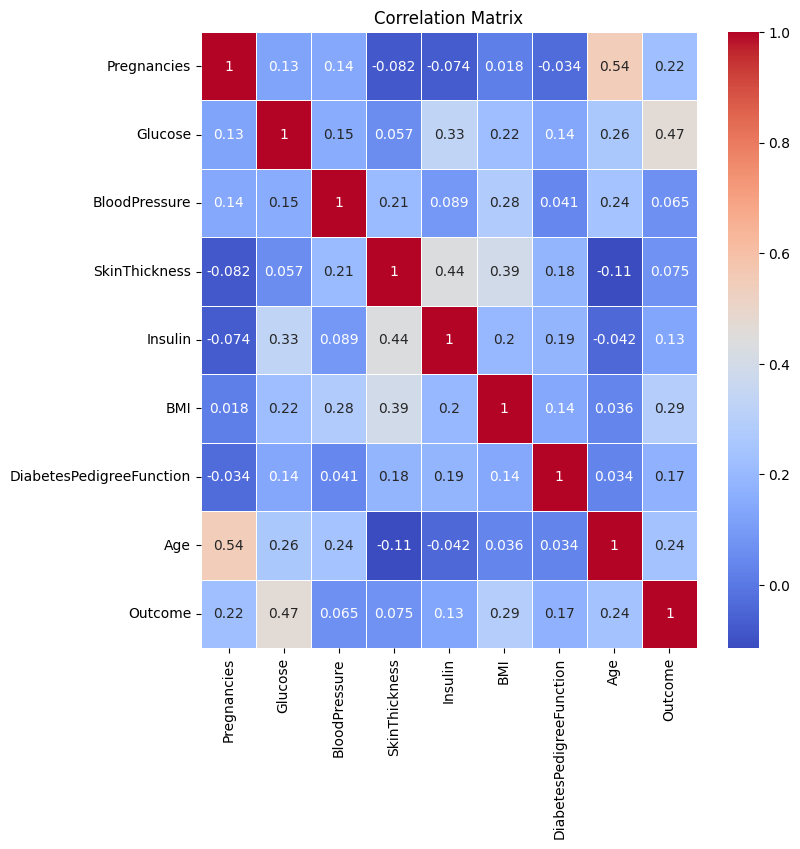

In [20]:
from correlation import correlation_matrix

correlation_matrix(dbt_df)

In [21]:
# Check for missing values
features.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

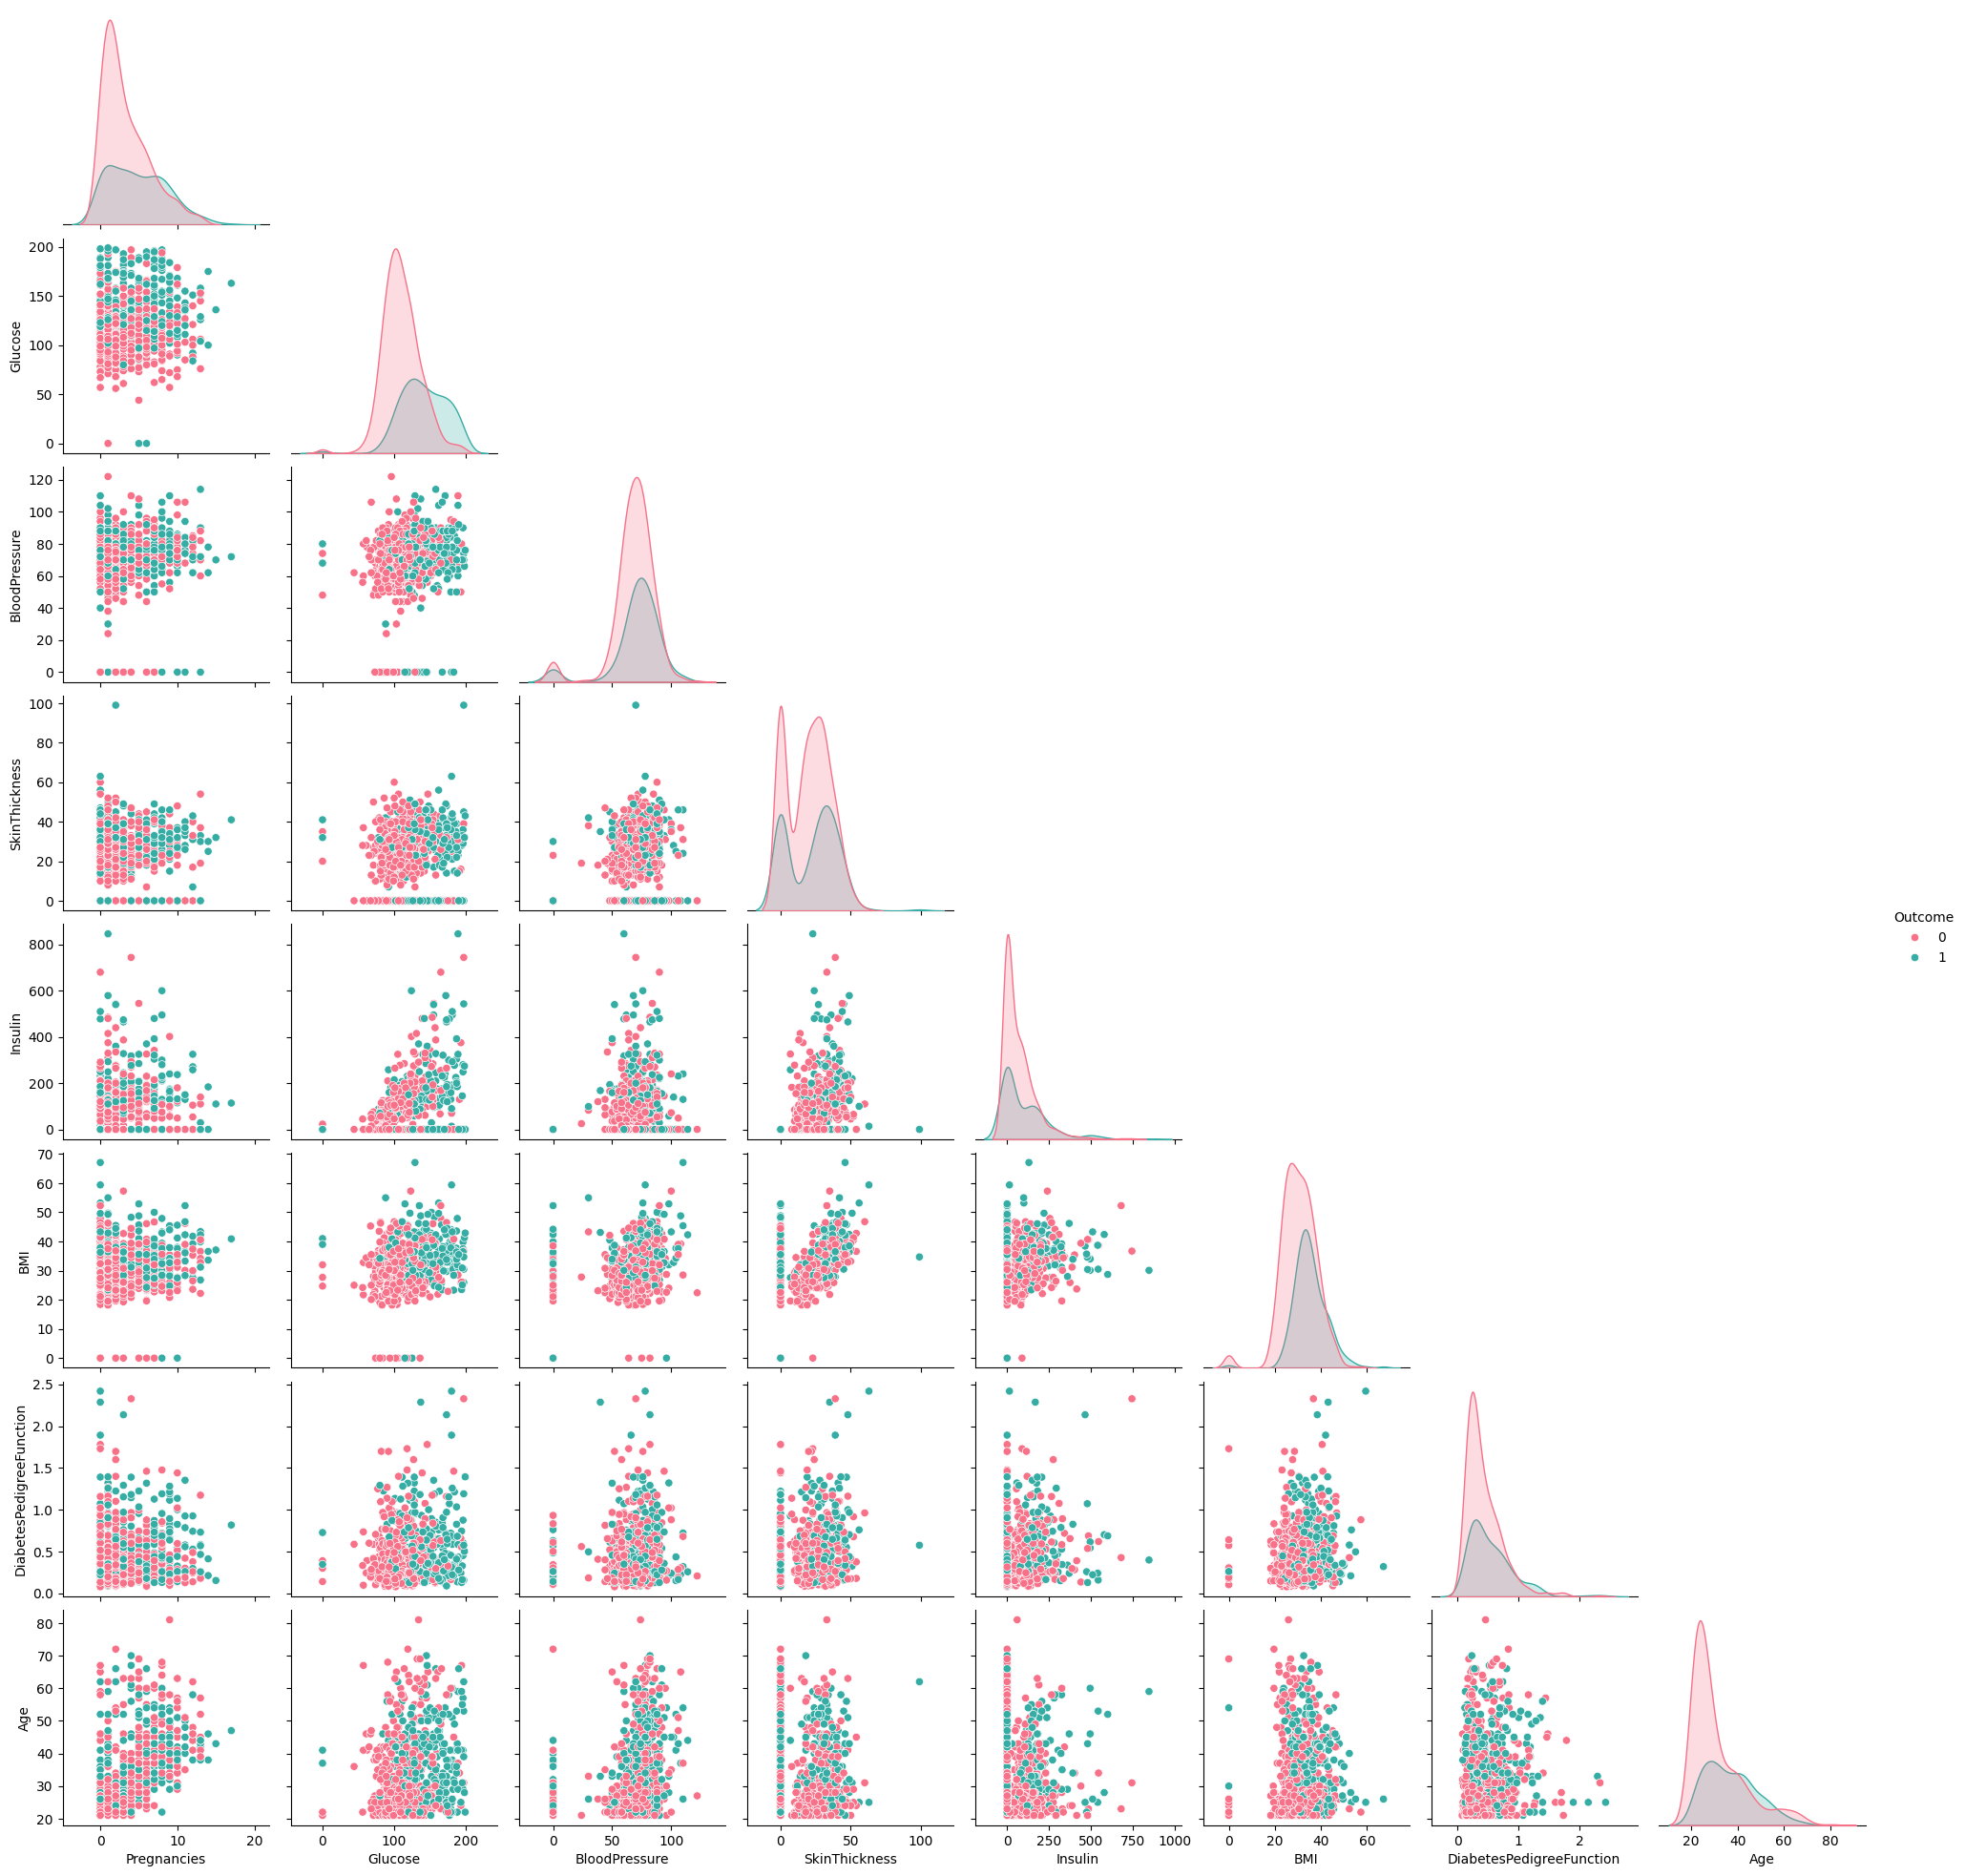

In [22]:
from distribution import plot_pairplot

plot_pairplot(dbt_df)

EDA Conclusions:

There are no missing values, so imputation is not necessary.

Outliers were detected using the IQR method.

Linear correlation between variables is low, suggesting that a nonlinear model might be more suitable.

Skewness Analysis:

Moderate Skewness: Pregnancies (0.90), Age (1.13).

Symmetric: Glucose (0.17), SkinThickness (0.11), BMI (-0.43).

Asymmetric: BloodPressure (-1.84), Insulin (2.27), DiabetesPedigreeFunction (1.92), Age (1.13).

Implications for Modeling:

Outliers: Transformations (log, sqrt) or robust methods may be necessary.

Skewness: Some variables might require normalization or transformation.

Model Choice: Consider nonlinear approaches; Base Line: Logistic Regression